# Heart Disease Prediction — AdaBoost Classifier

Boosting ensemble on the UCI Heart Disease dataset. AdaBoost sequentially trains weak learners, reweighting misclassified samples at each iteration.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

## 2. Load Data

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 3. Train-Test Split

In [3]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 4. Train AdaBoost

In [4]:
base_estimator = DecisionTreeClassifier(max_depth=1)

ada = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)

## 5. Evaluation

In [5]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-Score:  {f1:.4f}')

Accuracy:  0.8197
Precision: 0.7895
Recall:    0.9091
F1-Score:  0.8451


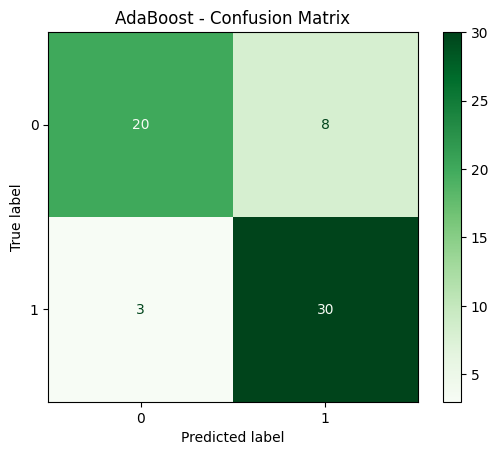

In [6]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Greens')
plt.title('AdaBoost - Confusion Matrix')
plt.show()

## 6. Accuracy vs Number of Estimators

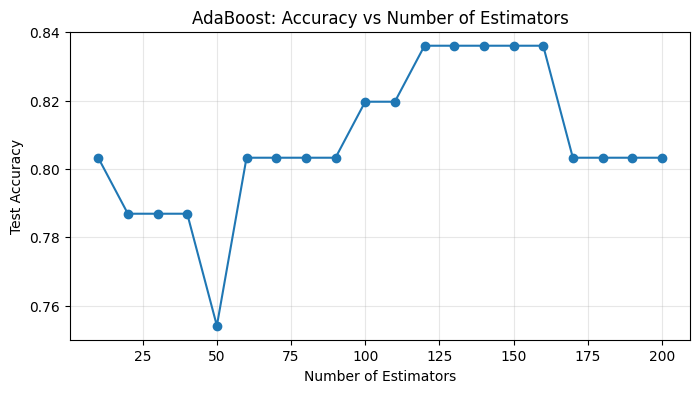

In [7]:
estimator_range = range(10, 201, 10)
accuracies = []

for n in estimator_range:
    model = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    accuracies.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.plot(list(estimator_range), accuracies, marker='o')
plt.xlabel('Number of Estimators')
plt.ylabel('Test Accuracy')
plt.title('AdaBoost: Accuracy vs Number of Estimators')
plt.grid(True, alpha=0.3)
plt.show()

## 7. Feature Importance

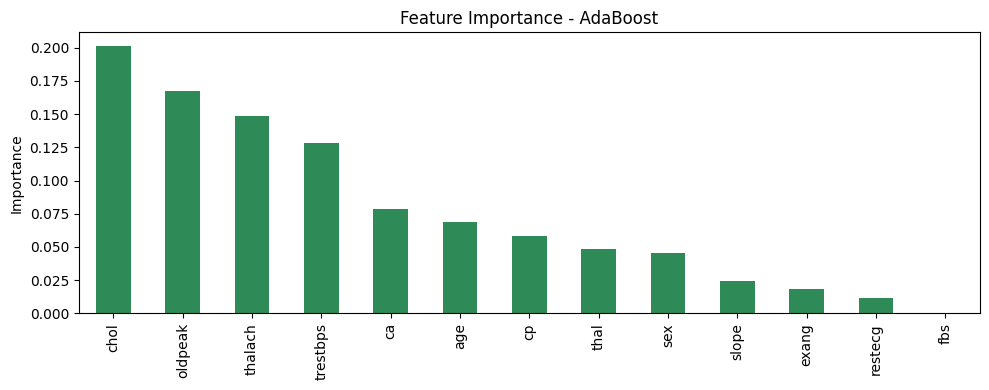

In [8]:
importances = pd.Series(ada.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='bar', figsize=(10, 4), title='Feature Importance - AdaBoost', color='seagreen')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()